# Test 20: SAE на GPT-2 — K ablation + Layer comparison

**Два эксперимента:**

### Эксперимент A: Ablation по K при 4x overcomplete
- Фиксированный overcomplete 4x (latent=3072), layer 6
- K = 1%, 5%, 10%, 20%, 50% от latent_dim (31, 154, 307, 614, 1536)
- Chaos a=1 vs ReLU, N=5 прогонов
- **Вопрос:** При каком K появляются dead neurons у ReLU?

### Эксперимент B: Сравнение по слоям GPT-2
- Layers: 0, 3, 6, 9, 11
- 4x overcomplete, K=10% (стандарт из теста 19)
- **Вопрос:** Зависит ли преимущество chaos от глубины слоя?

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import json
from datetime import datetime
import torch
from transformers import GPT2Model, GPT2Tokenizer
from datasets import load_dataset

print(f"TF version: {tf.__version__}")
print(f"GPU (TF): {tf.config.list_physical_devices('GPU')}")

TF version: 2.16.2
GPU (TF): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# === Извлечение активаций из ВСЕХ нужных слоёв ===

print("Загрузка GPT-2 small...")
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
gpt2_model = GPT2Model.from_pretrained('gpt2')
gpt2_model.eval()

ACTIVATION_DIM = 768
TARGET_LAYERS = [0, 3, 6, 9, 11]

print("Загрузка текстов...")
dataset = load_dataset('wikitext', 'wikitext-2-raw-v1', split='train')
texts = [t for t in dataset['text'] if len(t) > 100][:500]

print(f"Извлечение активаций из слоёв {TARGET_LAYERS}...")
layer_activations = {l: [] for l in TARGET_LAYERS}
tokenizer.pad_token = tokenizer.eos_token

with torch.no_grad():
    for i, text in enumerate(texts):
        inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=128)
        outputs = gpt2_model(**inputs, output_hidden_states=True)
        for layer_idx in TARGET_LAYERS:
            hidden = outputs.hidden_states[layer_idx]
            acts = hidden.squeeze(0).numpy()
            layer_activations[layer_idx].append(acts)
        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{len(texts)}")

# Нормализация для каждого слоя
layer_data = {}
for layer_idx in TARGET_LAYERS:
    acts = np.concatenate(layer_activations[layer_idx], axis=0).astype('float32')
    act_mean = acts.mean(axis=0, keepdims=True)
    act_std = acts.std(axis=0, keepdims=True) + 1e-8
    acts_norm = ((acts - act_mean) / act_std).astype('float32')
    
    np.random.seed(42)
    indices = np.random.permutation(len(acts_norm))
    split = int(len(indices) * 0.8)
    layer_data[layer_idx] = {
        'train': acts_norm[indices[:split]],
        'test': acts_norm[indices[split:]],
    }
    print(f"  Layer {layer_idx}: {acts_norm.shape}")

del gpt2_model, tokenizer, layer_activations
torch.cuda.empty_cache() if torch.cuda.is_available() else None
print("GPT-2 удалён. Активации сохранены.")

Загрузка GPT-2 small...
Загрузка текстов...
Извлечение активаций из слоёв [0, 3, 6, 9, 11]...
  100/500
  200/500
  300/500
  400/500
  500/500
  Layer 0: (54573, 768)
  Layer 3: (54573, 768)
  Layer 6: (54573, 768)
  Layer 9: (54573, 768)
  Layer 11: (54573, 768)
GPT-2 удалён. Активации сохранены.


In [5]:
# === SAE компоненты ===

class KSparseLayer(layers.Layer):
    def __init__(self, k=32, **kwargs):
        super().__init__(**kwargs)
        self.k = k

    def call(self, inputs, training=None):
        latent_dim = tf.shape(inputs)[1]
        _, indices = tf.nn.top_k(tf.abs(inputs), k=self.k, sorted=False)
        mask = tf.reduce_sum(
            tf.one_hot(indices, latent_dim, dtype=inputs.dtype), axis=1
        )
        return inputs * mask

    def get_config(self):
        config = super().get_config()
        config.update({"k": self.k})
        return config


def chaos_activation(x):
    return tf.sin(1.0 * x) + 0.5 * tf.tanh(4.0 * x)


def build_sae(input_dim, latent_dim, k_active, use_chaos=True):
    input_act = keras.Input(shape=(input_dim,))
    if use_chaos:
        x = layers.Dense(latent_dim, name='latent_pre')(input_act)
        x = layers.Activation(chaos_activation)(x)
    else:
        x = layers.Dense(latent_dim, activation='relu', name='latent_pre')(input_act)
    latent = KSparseLayer(k=k_active, name='latent_ksparse')(x)
    encoder = keras.Model(input_act, latent, name='encoder')
    decoded = layers.Dense(input_dim, name='decoder')(latent)
    autoencoder = keras.Model(input_act, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder


def run_experiment(x_train, x_test, input_dim, latent_dim, k_active, num_runs=5, epochs=10, batch_size=256):
    """Запуск N прогонов для Chaos и ReLU, возврат результатов."""
    exp_results = {}
    for method_name, use_chaos in [('Chaos_a1', True), ('TopK_ReLU', False)]:
        runs = []
        for run in range(num_runs):
            np.random.seed(run)
            tf.random.set_seed(run)
            
            ae, enc = build_sae(input_dim, latent_dim, k_active, use_chaos=use_chaos)
            ae.fit(x_train, x_train, epochs=epochs, batch_size=batch_size,
                   validation_data=(x_test, x_test), verbose=0)
            
            latents = enc.predict(x_test, verbose=0)
            dead = int(np.sum(np.all(np.abs(latents) < 1e-6, axis=0)))
            val_loss = float(ae.evaluate(x_test, x_test, verbose=0))
            
            runs.append({
                'val_loss': val_loss,
                'dead': dead,
                'dead_pct': dead / latent_dim * 100,
            })
            
            del ae, enc
            keras.backend.clear_session()
        
        exp_results[method_name] = runs
    return exp_results


print("SAE ready.")

SAE ready.


In [6]:
# === Эксперимент A: Ablation по K при 4x overcomplete (layer 6) ===

NUM_RUNS = 5
EPOCHS = 10
BATCH_SIZE = 256
INPUT_DIM = ACTIVATION_DIM  # 768
LATENT_DIM_4X = INPUT_DIM * 4  # 3072

K_PERCENTS = [1, 5, 10, 20, 50]

x_train_6 = layer_data[6]['train']
x_test_6 = layer_data[6]['test']

results_A = {}

for k_pct in K_PERCENTS:
    k_active = max(LATENT_DIM_4X * k_pct // 100, 1)
    
    print(f"\n{'='*60}")
    print(f"  K={k_pct}% → {k_active}/{LATENT_DIM_4X} active neurons")
    print(f"{'='*60}")
    
    exp = run_experiment(x_train_6, x_test_6, INPUT_DIM, LATENT_DIM_4X, k_active,
                         num_runs=NUM_RUNS, epochs=EPOCHS, batch_size=BATCH_SIZE)
    results_A[k_pct] = exp
    
    for method in ['Chaos_a1', 'TopK_ReLU']:
        runs = exp[method]
        losses = [r['val_loss'] for r in runs]
        deads = [r['dead'] for r in runs]
        dead_pcts = [r['dead_pct'] for r in runs]
        print(f"  {method:12s}: loss={np.mean(losses):.4f}±{np.std(losses):.4f}, "
              f"dead={np.mean(deads):.1f}/{LATENT_DIM_4X} ({np.mean(dead_pcts):.1f}%)")

print("\nЭксперимент A завершён.")


  K=1% → 30/3072 active neurons


2026-04-08 16:06:21.181472: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-04-08 16:06:21.181498: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-04-08 16:06:21.181501: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2026-04-08 16:06:21.181514: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-08 16:06:21.181522: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-08 16:06:21.457249: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  Chaos_a1    : loss=0.6421±0.0043, dead=0.0/3072 (0.0%)
  TopK_ReLU   : loss=0.3232±0.0006, dead=777.2/3072 (25.3%)

  K=5% → 153/3072 active neurons
  Chaos_a1    : loss=0.2282±0.0002, dead=0.0/3072 (0.0%)
  TopK_ReLU   : loss=0.2108±0.0002, dead=0.2/3072 (0.0%)

  K=10% → 307/3072 active neurons
  Chaos_a1    : loss=0.1646±0.0002, dead=0.0/3072 (0.0%)
  TopK_ReLU   : loss=0.1563±0.0002, dead=0.0/3072 (0.0%)

  K=20% → 614/3072 active neurons
  Chaos_a1    : loss=0.1046±0.0002, dead=0.0/3072 (0.0%)
  TopK_ReLU   : loss=0.0952±0.0002, dead=0.0/3072 (0.0%)

  K=50% → 1536/3072 active neurons
  Chaos_a1    : loss=0.0450±0.0002, dead=0.0/3072 (0.0%)
  TopK_ReLU   : loss=0.0255±0.0002, dead=0.0/3072 (0.0%)

Эксперимент A завершён.


In [7]:
# === Эксперимент B: Сравнение по слоям GPT-2 (4x, K=10%) ===

results_B = {}

for layer_idx in TARGET_LAYERS:
    x_train_l = layer_data[layer_idx]['train']
    x_test_l = layer_data[layer_idx]['test']
    
    latent_dim = INPUT_DIM * 4  # 3072
    k_active = latent_dim // 10  # 307
    
    print(f"\n{'='*60}")
    print(f"  Layer {layer_idx}: latent={latent_dim}, K={k_active}")
    print(f"{'='*60}")
    
    exp = run_experiment(x_train_l, x_test_l, INPUT_DIM, latent_dim, k_active,
                         num_runs=NUM_RUNS, epochs=EPOCHS, batch_size=BATCH_SIZE)
    results_B[layer_idx] = exp
    
    for method in ['Chaos_a1', 'TopK_ReLU']:
        runs = exp[method]
        losses = [r['val_loss'] for r in runs]
        deads = [r['dead'] for r in runs]
        dead_pcts = [r['dead_pct'] for r in runs]
        print(f"  {method:12s}: loss={np.mean(losses):.4f}±{np.std(losses):.4f}, "
              f"dead={np.mean(deads):.1f}/{latent_dim} ({np.mean(dead_pcts):.1f}%)")

print("\nЭксперимент B завершён.")


  Layer 0: latent=3072, K=307
  Chaos_a1    : loss=0.1113±0.0007, dead=0.0/3072 (0.0%)
  TopK_ReLU   : loss=0.1110±0.0004, dead=0.0/3072 (0.0%)

  Layer 3: latent=3072, K=307
  Chaos_a1    : loss=0.1345±0.0002, dead=0.0/3072 (0.0%)
  TopK_ReLU   : loss=0.1289±0.0005, dead=0.0/3072 (0.0%)

  Layer 6: latent=3072, K=307
  Chaos_a1    : loss=0.1646±0.0003, dead=0.0/3072 (0.0%)
  TopK_ReLU   : loss=0.1565±0.0003, dead=0.0/3072 (0.0%)

  Layer 9: latent=3072, K=307
  Chaos_a1    : loss=0.1750±0.0001, dead=0.0/3072 (0.0%)
  TopK_ReLU   : loss=0.1621±0.0003, dead=0.0/3072 (0.0%)

  Layer 11: latent=3072, K=307
  Chaos_a1    : loss=0.1774±0.0002, dead=0.0/3072 (0.0%)
  TopK_ReLU   : loss=0.1578±0.0003, dead=0.0/3072 (0.0%)

Эксперимент B завершён.


In [8]:
# === Сводные таблицы ===

# --- Таблица A: K ablation ---
print("=" * 80)
print("ЭКСПЕРИМЕНТ A: Ablation по K (4x overcomplete, layer 6)")
print("=" * 80)
print(f"{'K%':>5} {'K':>6} {'Метод':<12} {'Loss':>12} {'Dead':>10} {'Dead%':>8}")
print('-' * 70)

summary_A = {}
for k_pct in K_PERCENTS:
    k_active = max(LATENT_DIM_4X * k_pct // 100, 1)
    summary_A[k_pct] = {}
    for method in ['Chaos_a1', 'TopK_ReLU']:
        runs = results_A[k_pct][method]
        s = {
            'loss_mean': np.mean([r['val_loss'] for r in runs]),
            'loss_std': np.std([r['val_loss'] for r in runs]),
            'dead_mean': np.mean([r['dead'] for r in runs]),
            'dead_pct_mean': np.mean([r['dead_pct'] for r in runs]),
        }
        summary_A[k_pct][method] = s
        print(f"{k_pct:>4}% {k_active:>6} {method:<12} "
              f"{s['loss_mean']:>8.4f}±{s['loss_std']:.4f} "
              f"{s['dead_mean']:>8.1f} {s['dead_pct_mean']:>7.1f}%")
    print()

# --- Таблица B: Layer comparison ---
print("\n" + "=" * 80)
print("ЭКСПЕРИМЕНТ B: Сравнение по слоям GPT-2 (4x, K=10%)")
print("=" * 80)
print(f"{'Layer':>6} {'Метод':<12} {'Loss':>12} {'Dead':>10} {'Dead%':>8}")
print('-' * 60)

summary_B = {}
for layer_idx in TARGET_LAYERS:
    summary_B[layer_idx] = {}
    for method in ['Chaos_a1', 'TopK_ReLU']:
        runs = results_B[layer_idx][method]
        s = {
            'loss_mean': np.mean([r['val_loss'] for r in runs]),
            'loss_std': np.std([r['val_loss'] for r in runs]),
            'dead_mean': np.mean([r['dead'] for r in runs]),
            'dead_pct_mean': np.mean([r['dead_pct'] for r in runs]),
        }
        summary_B[layer_idx][method] = s
        print(f"{layer_idx:>6} {method:<12} "
              f"{s['loss_mean']:>8.4f}±{s['loss_std']:.4f} "
              f"{s['dead_mean']:>8.1f} {s['dead_pct_mean']:>7.1f}%")
    print()

ЭКСПЕРИМЕНТ A: Ablation по K (4x overcomplete, layer 6)
   K%      K Метод                Loss       Dead    Dead%
----------------------------------------------------------------------
   1%     30 Chaos_a1       0.6421±0.0043      0.0     0.0%
   1%     30 TopK_ReLU      0.3232±0.0006    777.2    25.3%

   5%    153 Chaos_a1       0.2282±0.0002      0.0     0.0%
   5%    153 TopK_ReLU      0.2108±0.0002      0.2     0.0%

  10%    307 Chaos_a1       0.1646±0.0002      0.0     0.0%
  10%    307 TopK_ReLU      0.1563±0.0002      0.0     0.0%

  20%    614 Chaos_a1       0.1046±0.0002      0.0     0.0%
  20%    614 TopK_ReLU      0.0952±0.0002      0.0     0.0%

  50%   1536 Chaos_a1       0.0450±0.0002      0.0     0.0%
  50%   1536 TopK_ReLU      0.0255±0.0002      0.0     0.0%


ЭКСПЕРИМЕНТ B: Сравнение по слоям GPT-2 (4x, K=10%)
 Layer Метод                Loss       Dead    Dead%
------------------------------------------------------------
     0 Chaos_a1       0.1113±0.0007      0

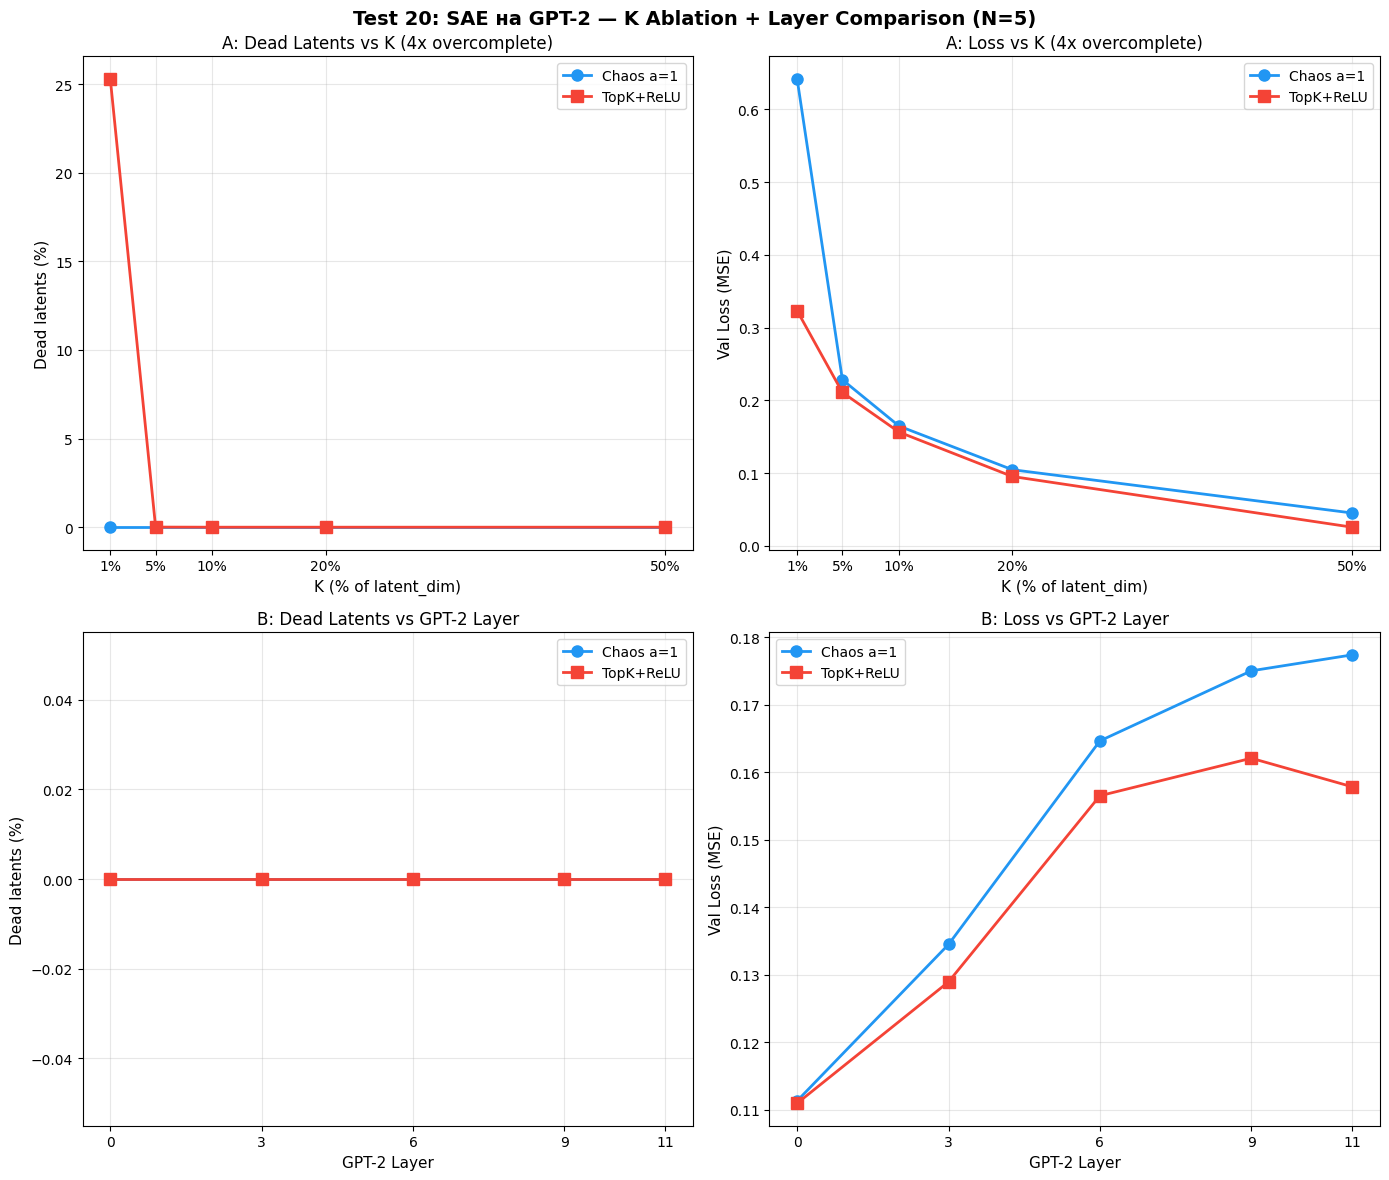

In [9]:
# === Визуализация ===

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# --- A1: Dead neurons vs K% ---
k_vals = K_PERCENTS
chaos_dead_A = [summary_A[k]['Chaos_a1']['dead_pct_mean'] for k in k_vals]
relu_dead_A = [summary_A[k]['TopK_ReLU']['dead_pct_mean'] for k in k_vals]

axes[0, 0].plot(k_vals, chaos_dead_A, 'o-', color='#2196F3', lw=2, ms=8, label='Chaos a=1')
axes[0, 0].plot(k_vals, relu_dead_A, 's-', color='#F44336', lw=2, ms=8, label='TopK+ReLU')
axes[0, 0].set_xlabel('K (% of latent_dim)', fontsize=11)
axes[0, 0].set_ylabel('Dead latents (%)', fontsize=11)
axes[0, 0].set_title('A: Dead Latents vs K (4x overcomplete)')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(k_vals)
axes[0, 0].set_xticklabels([f'{k}%' for k in k_vals])

# --- A2: Loss vs K% ---
chaos_loss_A = [summary_A[k]['Chaos_a1']['loss_mean'] for k in k_vals]
relu_loss_A = [summary_A[k]['TopK_ReLU']['loss_mean'] for k in k_vals]

axes[0, 1].plot(k_vals, chaos_loss_A, 'o-', color='#2196F3', lw=2, ms=8, label='Chaos a=1')
axes[0, 1].plot(k_vals, relu_loss_A, 's-', color='#F44336', lw=2, ms=8, label='TopK+ReLU')
axes[0, 1].set_xlabel('K (% of latent_dim)', fontsize=11)
axes[0, 1].set_ylabel('Val Loss (MSE)', fontsize=11)
axes[0, 1].set_title('A: Loss vs K (4x overcomplete)')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks(k_vals)
axes[0, 1].set_xticklabels([f'{k}%' for k in k_vals])

# --- B1: Dead neurons vs Layer ---
layer_vals = TARGET_LAYERS
chaos_dead_B = [summary_B[l]['Chaos_a1']['dead_pct_mean'] for l in layer_vals]
relu_dead_B = [summary_B[l]['TopK_ReLU']['dead_pct_mean'] for l in layer_vals]

axes[1, 0].plot(layer_vals, chaos_dead_B, 'o-', color='#2196F3', lw=2, ms=8, label='Chaos a=1')
axes[1, 0].plot(layer_vals, relu_dead_B, 's-', color='#F44336', lw=2, ms=8, label='TopK+ReLU')
axes[1, 0].set_xlabel('GPT-2 Layer', fontsize=11)
axes[1, 0].set_ylabel('Dead latents (%)', fontsize=11)
axes[1, 0].set_title('B: Dead Latents vs GPT-2 Layer')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xticks(layer_vals)

# --- B2: Loss vs Layer ---
chaos_loss_B = [summary_B[l]['Chaos_a1']['loss_mean'] for l in layer_vals]
relu_loss_B = [summary_B[l]['TopK_ReLU']['loss_mean'] for l in layer_vals]

axes[1, 1].plot(layer_vals, chaos_loss_B, 'o-', color='#2196F3', lw=2, ms=8, label='Chaos a=1')
axes[1, 1].plot(layer_vals, relu_loss_B, 's-', color='#F44336', lw=2, ms=8, label='TopK+ReLU')
axes[1, 1].set_xlabel('GPT-2 Layer', fontsize=11)
axes[1, 1].set_ylabel('Val Loss (MSE)', fontsize=11)
axes[1, 1].set_title('B: Loss vs GPT-2 Layer')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xticks(layer_vals)

plt.suptitle(f'Test 20: SAE на GPT-2 — K Ablation + Layer Comparison (N={NUM_RUNS})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# === Сохранение ===
save_data = {
    'experiment': 'llm_k_ablation_layer_comparison',
    'timestamp': datetime.now().isoformat(),
    'config': {
        'llm_model': 'gpt2',
        'activation_dim': ACTIVATION_DIM,
        'experiment_A': {
            'description': 'K ablation at 4x overcomplete, layer 6',
            'latent_dim': LATENT_DIM_4X,
            'k_percents': K_PERCENTS,
        },
        'experiment_B': {
            'description': 'Layer comparison at 4x overcomplete, K=10%',
            'target_layers': TARGET_LAYERS,
        },
        'num_runs': NUM_RUNS,
        'epochs': EPOCHS,
    },
    'results_A': {str(k): v for k, v in results_A.items()},
    'results_B': {str(k): v for k, v in results_B.items()},
    'summary_A': {str(k): v for k, v in summary_A.items()},
    'summary_B': {str(k): v for k, v in summary_B.items()},
}

json_path = f'../jsons/llm_k_ablation_layers_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json'
with open(json_path, 'w') as f:
    json.dump(save_data, f, indent=2, default=str)
print(f"Results saved: {json_path}")

Results saved: ../jsons/llm_k_ablation_layers_20260408_174732.json
